<a href="https://colab.research.google.com/github.com/mariiam36/EML_MontesinosOlivaOuardi/blob/main/k_brazos/bandit_experiment_todos_los_algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLE - Práctica 1 parte 1**
***Máster en Inteligencia Artificial - Universidad de Murcia***

**Hecho por**: 
- Jorge Montesinos Bravo
- Manuel Oliva Marín
- Mariam Ouardi Bennane

**Profesor**: Luis Daniel Hernández Molinero

**Fecha**: 15/03/2026

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.


This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [ ]:
!git clone https://github.com/mariiam36/EML_MontesinosOlivaOuardi.git
!cd EML_MontesinosOlivaOuardi/k_brazos

In [ ]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
# sys.path.append('/content/k_brazos')


# Verificar que se han añadido correctamente
# print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, UCB1, Softmax
from arms import ArmBernoulli, ArmBinomial, ArmNormal, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret
from utils.fix_seed import fix_seed

In [ ]:
fix_seed(42)

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [2]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    # Nueva matriz para el regret acumulado
    regret_accumulated = np.zeros((len(algorithms), steps))

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        # Necesitamos llevar la cuenta del regret acumulado en este 'run' específico
        current_run_regret = np.zeros(len(algorithms))

        for step in range(steps):
            # Simulamos qué habría pasado si elegimos el brazo óptimo
            # Tiramos del brazo óptimo para saber qué recompensa máxima podríamos haber tenido
            optimal_reward = current_bandit.pull_arm(optimal_arm)
            
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.
                # print(reward)
                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                # Cálculo del Regret del paso actual: (Media Óptima - Media del brazo elegido)
                # Es la diferencia entre la recompensa óptima y la obtenida
                step_regret = optimal_reward - reward
                current_run_regret[idx] += step_regret
                regret_accumulated[idx, step] += current_run_regret[idx]

                #TODO: modificar optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

    rewards /= runs

    # TODO: calcular el porcentaje de selecciones óptimas y almacenar en optimal_selections
    optimal_selections = (optimal_selections / runs) * 100
    
    regret_accumulated /= runs

    return rewards, optimal_selections, regret_accumulated


## Ejecución de experimentos

Se realiza el experimento usando 10 brazos, donde en cada apartado se prueba una distribución diferente. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan todos los algoritmos.

### Distribución Normal

In [ ]:
# Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), UCB1(k=k), Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


#### Visualización de los resultados

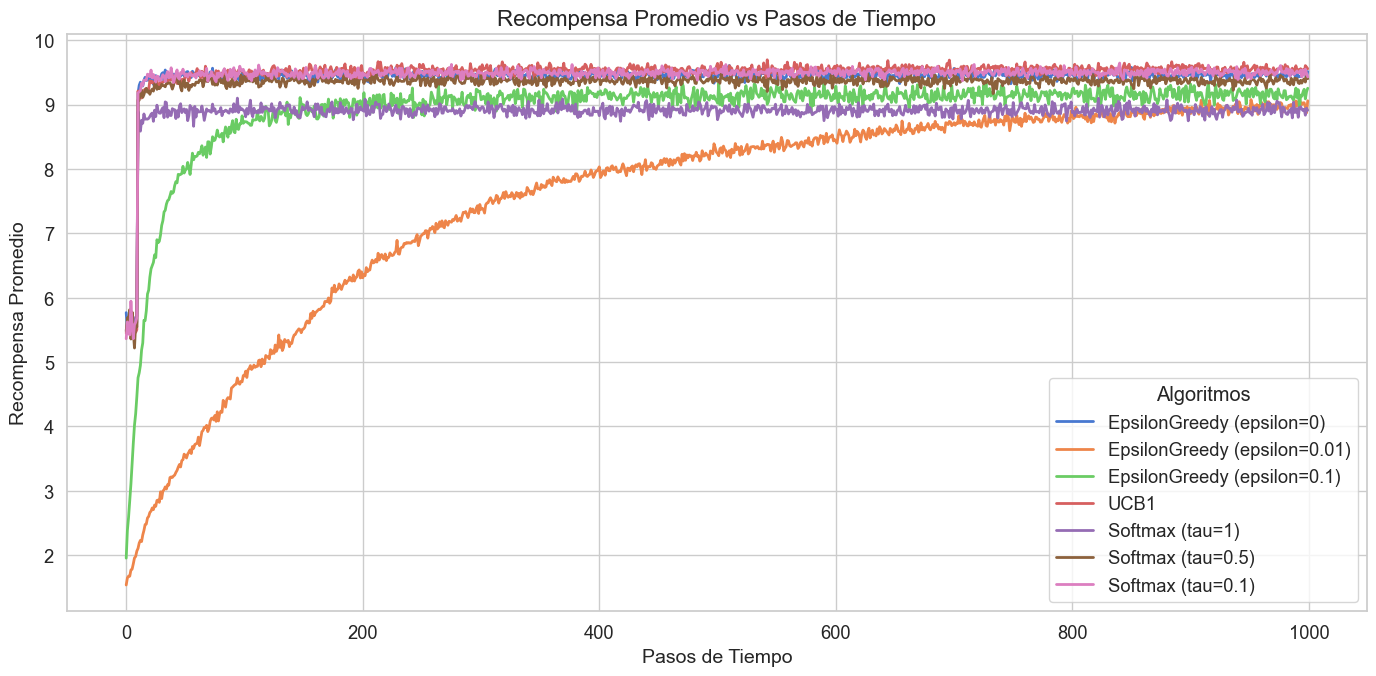

In [4]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)

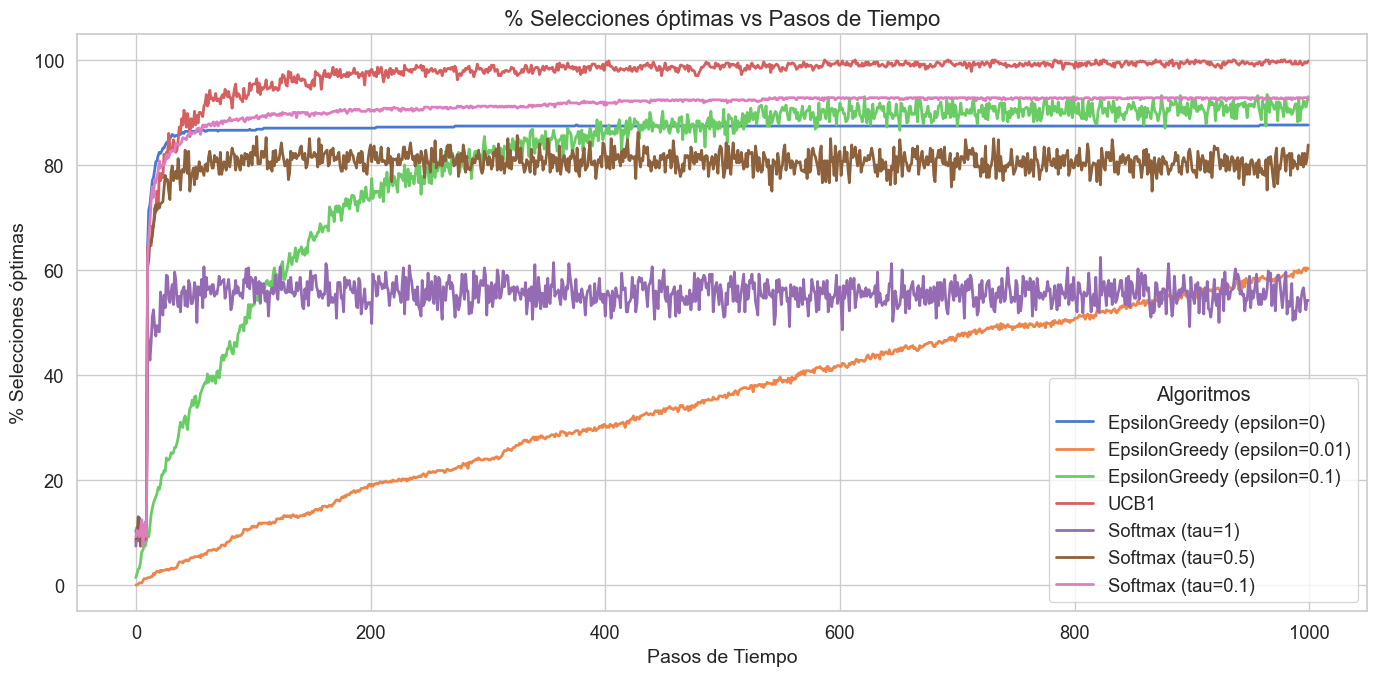

In [5]:
plot_optimal_selections(steps, optimal_selections, algorithms)

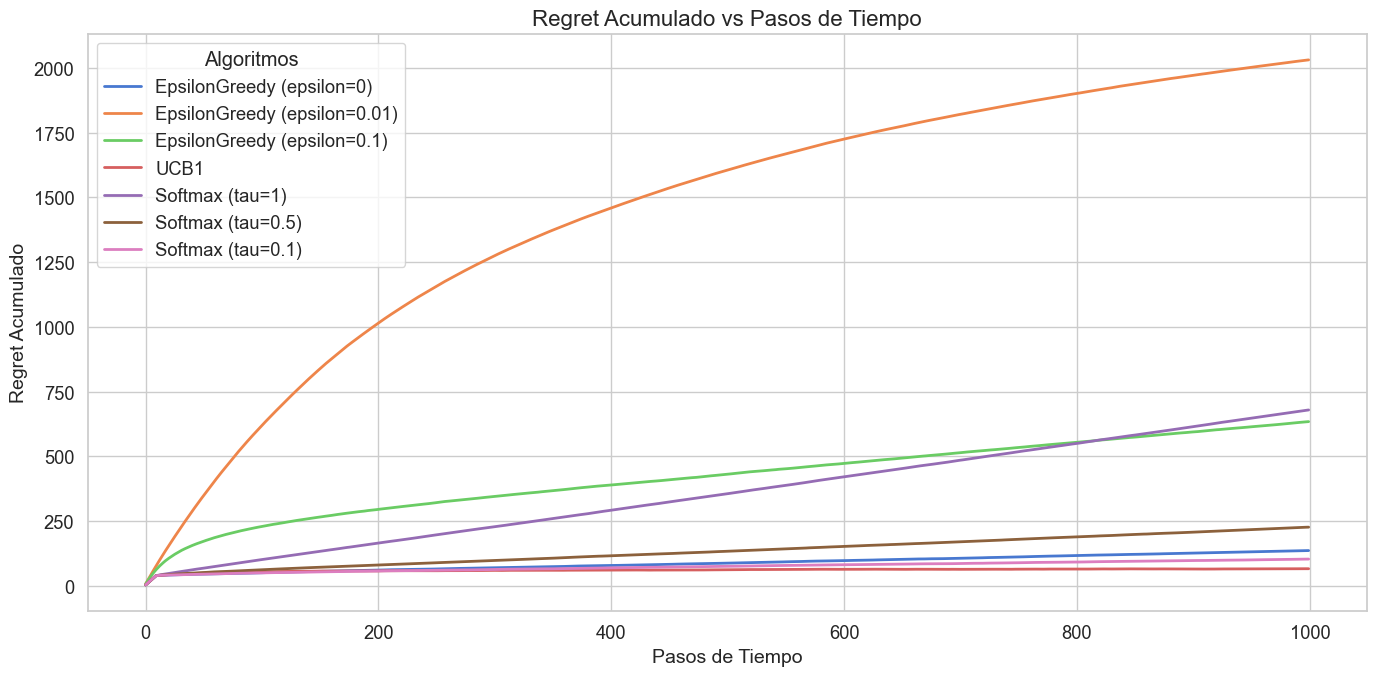

In [6]:
plot_regret(steps, regret_accumulated, algorithms)

### Distribución Binomial

In [ ]:
# Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), UCB1(k=k), Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.4), ArmBinomial(n=10, p=0.86), ArmBinomial(n=10, p=0.22), ArmBinomial(n=10, p=0.69), ArmBinomial(n=10, p=0.58), ArmBinomial(n=10, p=0.15), ArmBinomial(n=10, p=0.79), ArmBinomial(n=10, p=0.67), ArmBinomial(n=10, p=0.12), ArmBinomial(n=10, p=0.88)
Optimal arm: 10 with expected reward=8.8


#### Visualización de los resultados

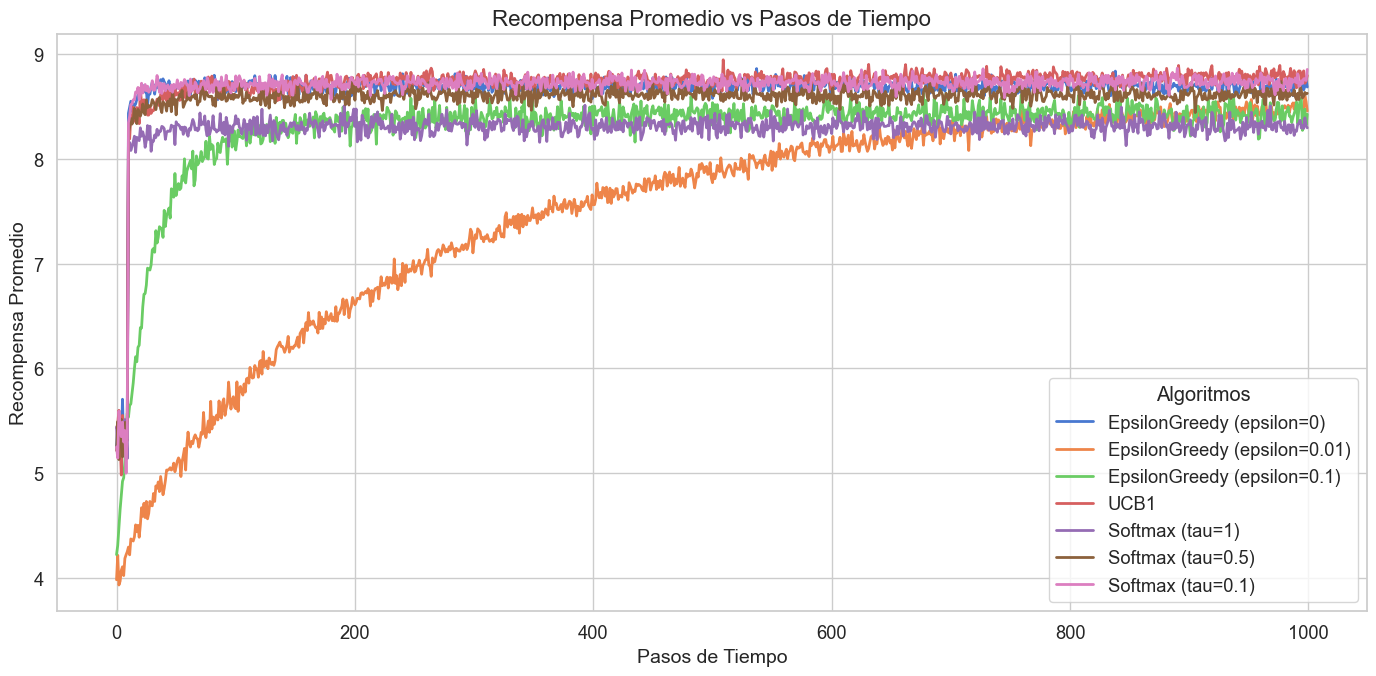

In [16]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)

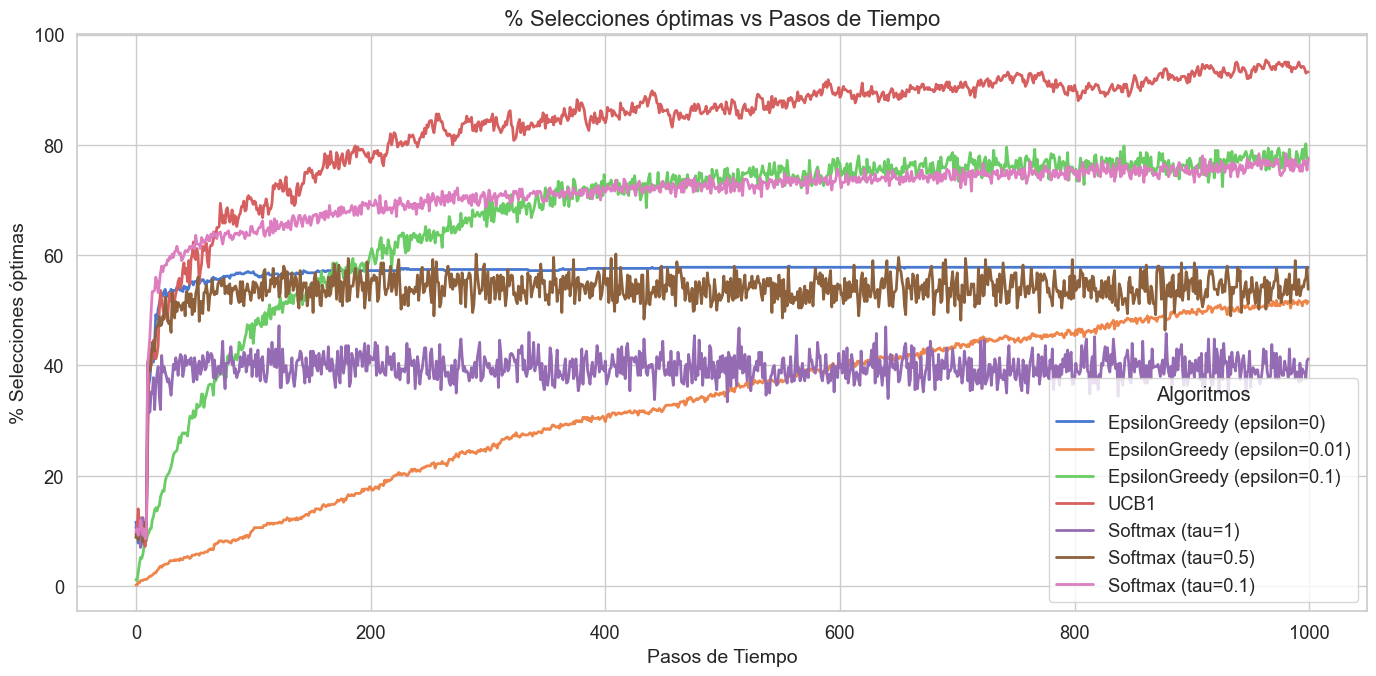

In [17]:
plot_optimal_selections(steps, optimal_selections, algorithms)

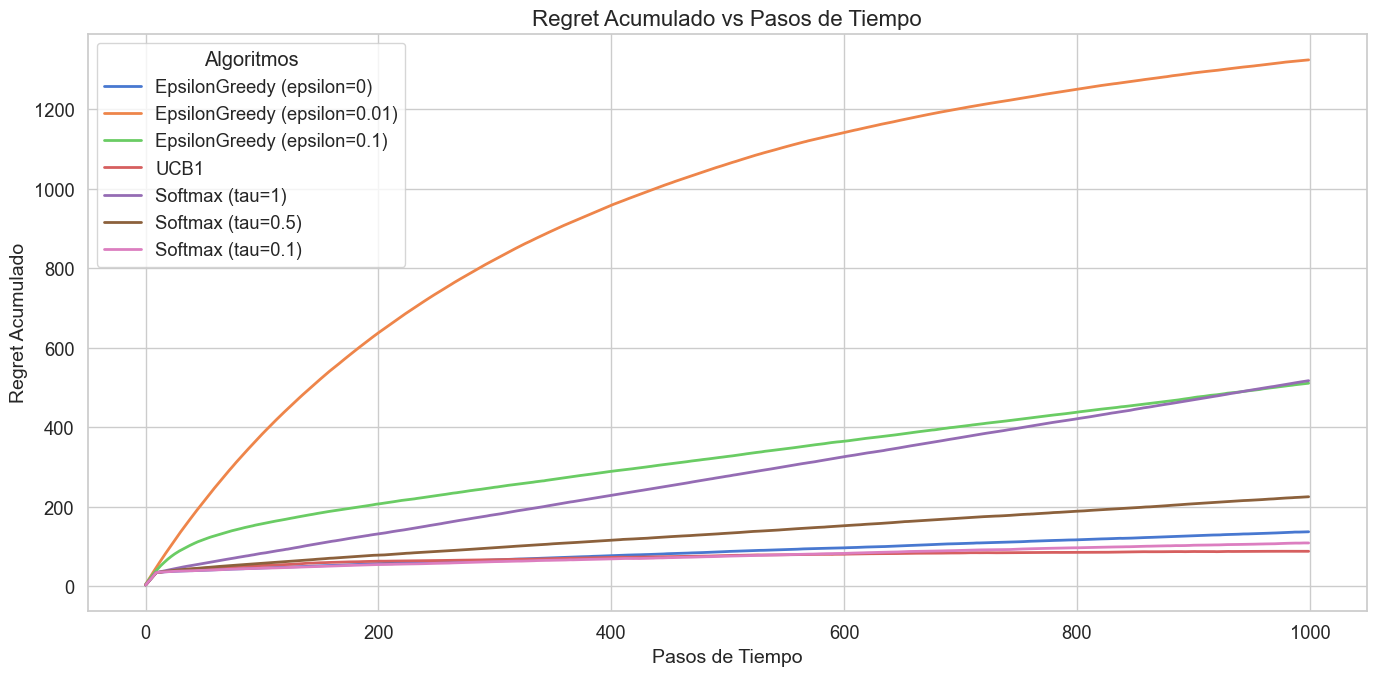

In [18]:
plot_regret(steps, regret_accumulated, algorithms)

### Distribución Bernoulli

In [ ]:
# Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), UCB1(k=k), Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.4, n=1), ArmBernoulli(p=0.86, n=1), ArmBernoulli(p=0.22, n=1), ArmBernoulli(p=0.69, n=1), ArmBernoulli(p=0.58, n=1), ArmBernoulli(p=0.15, n=1), ArmBernoulli(p=0.79, n=1), ArmBernoulli(p=0.67, n=1), ArmBernoulli(p=0.12, n=1), ArmBernoulli(p=0.88, n=1)
Optimal arm: 10 with expected reward=0.88


#### Visualización de los resultados

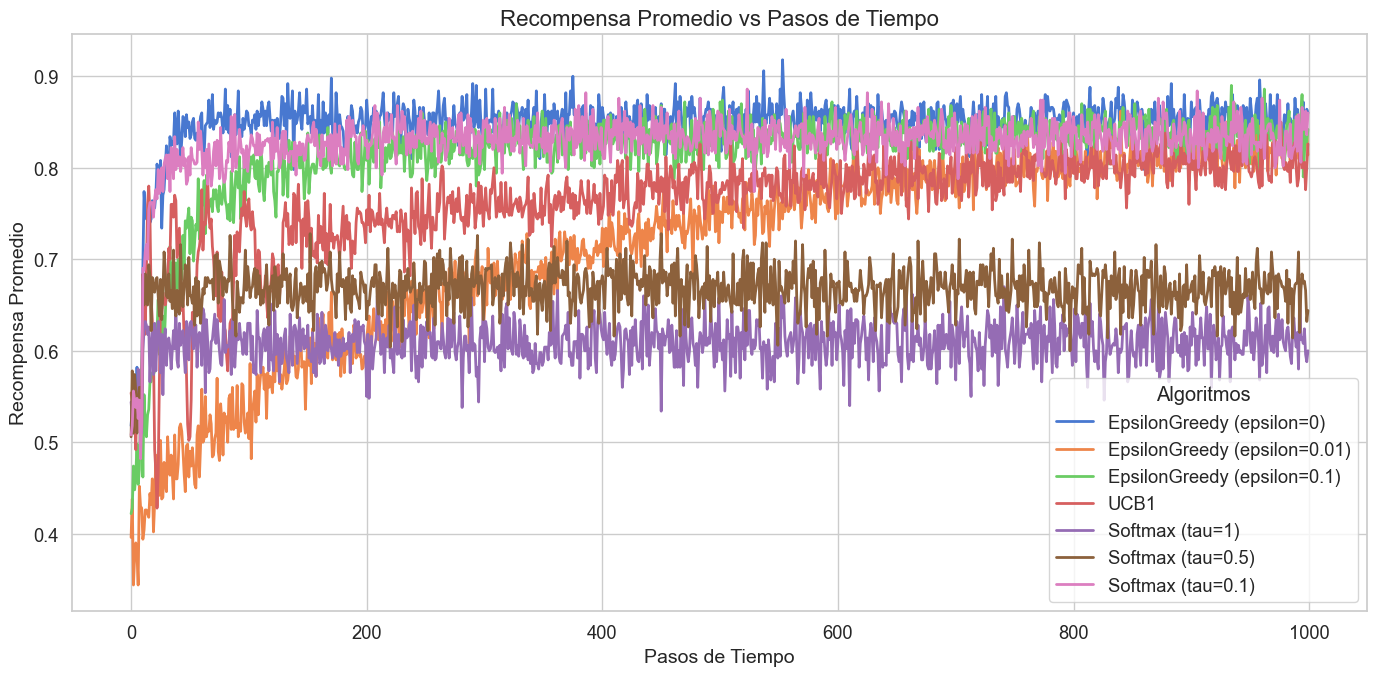

In [20]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)

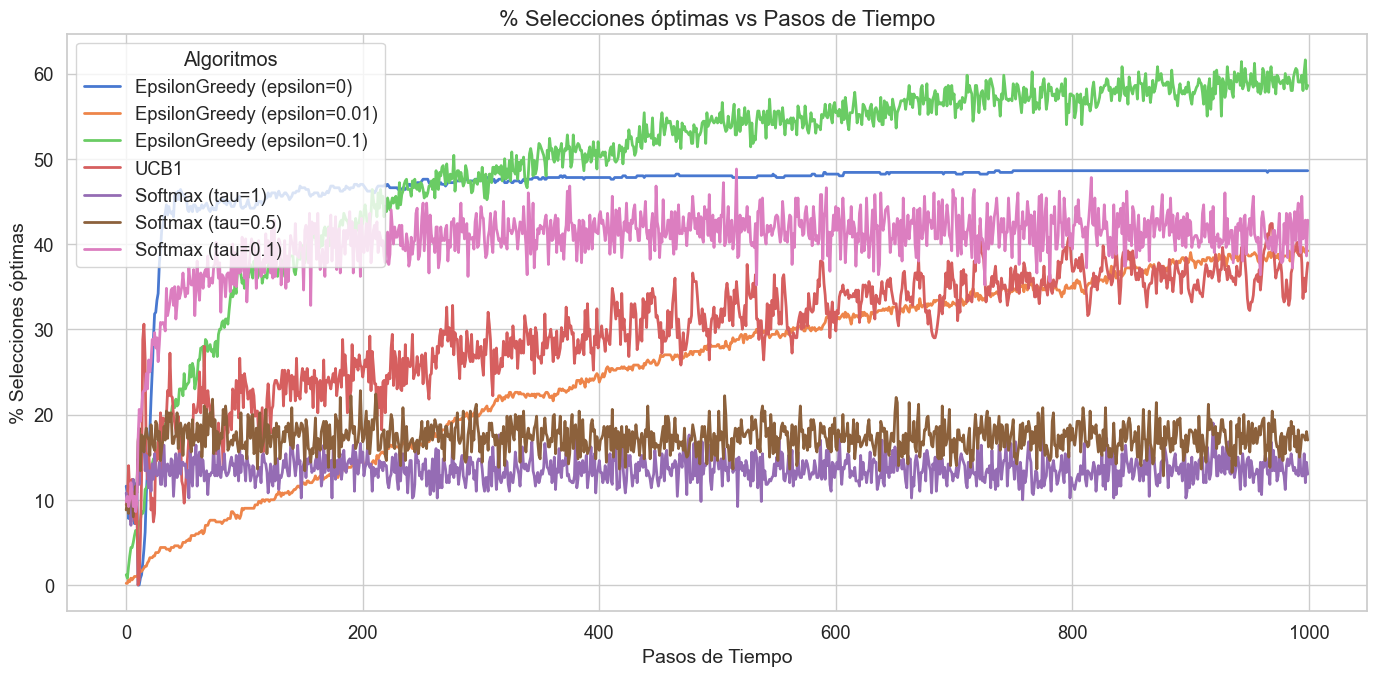

In [21]:
plot_optimal_selections(steps, optimal_selections, algorithms)

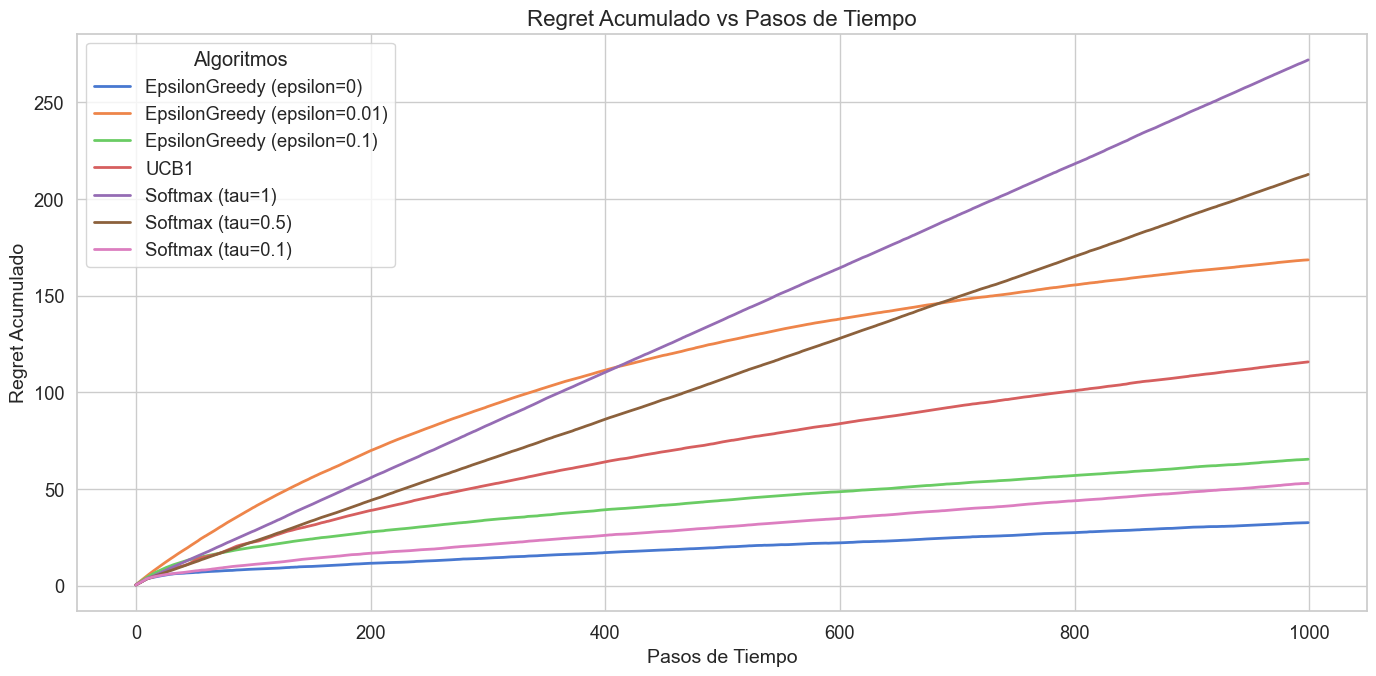

In [22]:
plot_regret(steps, regret_accumulated, algorithms)